<a href="https://colab.research.google.com/github/deepakawl/supplychain-analytics-teaching/blob/main/Network_Analysis_in_Supply_Chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Network Analysis in Supply Chain

## Prepared by: Deepak Agrawal, www.dagrawal.com
Generated using Claude AI to sync with session slides.

---
## Setup — run once per session

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

from google.colab import files; files.upload()

# international company names need latin-1
nodes = pd.read_csv('sc_nodes.csv', encoding='latin-1')
links = pd.read_csv('sc_links.csv', encoding='latin-1')

# one relationship per pair; parse dates
links['startdate'] = pd.to_datetime(links['startdate'], format='%d%b%Y')
links = links.sort_values('startdate').drop_duplicates(['s_feid', 't_feid'], keep='first')

names = nodes.set_index('feid')['entity_proper_name']   # handy lookup used throughout
print(f"{len(nodes):,} firms in node file | {len(links):,} unique relationships")

Saving sc_links.csv to sc_links.csv
Saving sc_nodes.csv to sc_nodes.csv
56,660 firms in node file | 386,766 unique relationships


---
---
# Network Metrics


### ▶ *Starting point: a graph object*

In [2]:
# build the directed graph once; every metric below runs on it
G = nx.from_pandas_edgelist(
        links, source='s_feid', target='t_feid',
        create_using=nx.DiGraph())                 # DiGraph = keep supplier -> customer direction
nx.set_node_attributes(G, nodes.set_index('feid').to_dict('index'))

print(G.number_of_nodes(), "firms |", G.number_of_edges(), "supply relationships")

140903 firms | 386766 supply relationships


### ▶ *Distance and shortest paths*

In [29]:
# pick two real firms: a supplier-of-a-supplier of Boeing, and Boeing
focal_firm_name = 'Boeing Co'
cand = nodes.loc[nodes['entity_proper_name'].str.contains(focal_firm_name, na=False), 'feid']
boeing = max((f for f in cand if f in G), key=lambda f: G.degree(f))   # a match that's actually in G
up2 = nx.single_source_shortest_path_length(G.reverse(copy=False), boeing, cutoff=2)
a_tier2_supplier = [f for f, d in up2.items() if d == 2][0]

In [31]:
# the actual route, and its length (= tier depth)
route = nx.shortest_path(G, a_tier2_supplier, boeing)
print("route:", " -> ".join(names.get(f, f) for f in route))
print("distance (tiers):", nx.shortest_path_length(G, a_tier2_supplier, boeing))

route: Amazon.com, Inc. -> Mulesoft LLC -> The Boeing Co.
distance (tiers): 2


In [32]:
# reachability: everything downstream of a hub (the full footprint of a disruption)
hub = pd.Series(dict(G.out_degree())).idxmax()
print(f"{names.get(hub, hub)} can reach {len(nx.descendants(G, hub)):,} firms downstream")

Alphabet, Inc. can reach 74,893 firms downstream


### ▶ *Degree centrality: Finding the Hubs*

In [6]:
out_deg = pd.Series(dict(G.out_degree()))     # customers per firm
print("Most customers (widely used suppliers):")
print(out_deg.sort_values(ascending=False).head(10).rename(names).to_string())

Most customers (widely used suppliers):
Alphabet, Inc.                   1594
Amazon.com, Inc.                 1477
Microsoft Corp.                  1240
Apple, Inc.                       907
Oracle Corp.                      657
Alibaba Group Holding Ltd.        583
Berkshire Hathaway, Inc.          487
MEDIA DO Co., Ltd.                455
JD.com, Inc.                      453
Samsung Electronics Co., Ltd.     423


In [7]:
in_deg = pd.Series(dict(G.in_degree()))       # suppliers per firm
print("Most suppliers (large assemblers / buyers):")
print(in_deg.sort_values(ascending=False).head(10).rename(names).to_string())
# (some IDs show without a name = firm appears in links but not the node file - mention this on camera)

Most suppliers (large assemblers / buyers):
05MCSG-E                         1044
Samsung Electronics Co., Ltd.    1011
Amazon.com, Inc.                  821
Volkswagen AG                     778
Toyota Motor Corp.                718
General Motors Co.                645
Walmart, Inc.                     624
Apple, Inc.                       614
Mercedes-Benz Group AG            607
Bayerische Motoren Werke AG       568


### ▶ *Betweenness centrality*

Note: exact betweenness here would take hours. We sample source nodes with `k`. `k=30` ≈ ~20s; raise it for a sharper ranking.

In [8]:
import time
giant = max(nx.weakly_connected_components(G), key=len)
Gg = G.subgraph(giant)

t = time.time()
btw = nx.betweenness_centrality(Gg, k=30, seed=42)     # SAMPLED - the scale trick
print(f"computed in {time.time()-t:.0f}s")

print("Top chokepoints (highest betweenness):")
print(pd.Series(btw).sort_values(ascending=False).head(10).rename(names).to_string())

computed in 24s
Top chokepoints (highest betweenness):
Amazon.com, Inc.                         0.030140
Apple, Inc.                              0.018491
Walmart, Inc.                            0.018113
Taiyo Holdings Co., Ltd.                 0.017101
Shell Plc                                0.016399
SNP Schneider-Neureither & Partner SE    0.015773
Microsoft Corp.                          0.014840
The Go-Ahead Group Plc                   0.013483
Textron, Inc.                            0.012323
Evergy, Inc.                             0.012277


### ▶ *Closeness and PageRank*
*"pagerank on the full graph (fast); closeness-on-subgraph"*

Note: Closeness centrality computation can be slow on large data.

In [9]:
# PageRank scales to the full graph - runs in seconds
pr = pd.Series(nx.pagerank(G))
print("Top by PageRank (systemic importance):")
print(pr.sort_values(ascending=False).head(10).rename(names).to_string())

Top by PageRank (systemic importance):
05MCSG-E                         0.002230
DNOW, Inc.                       0.001090
Amazon.com, Inc.                 0.001066
Apple, Inc.                      0.001015
Samsung Electronics Co., Ltd.    0.000955
Covetrus, Inc.                   0.000889
Airtel Malawi Plc                0.000862
05LT05-E                         0.000857
Walmart, Inc.                    0.000850
VICIS New Investments SA         0.000818


In [12]:
# closeness is costly on the full directed graph -> compute on a subgraph you care about
H = G.subgraph(nx.descendants(G, boeing) | {boeing})
clo = pd.Series(nx.closeness_centrality(H))
print(f"closeness computed on Boeing's downstream subgraph ({H.number_of_nodes():,} firms)")
print(clo.sort_values(ascending=False).head(5).rename(names).to_string())

closeness computed on Boeing's downstream subgraph (74,894 firms)
05MCSG-E                         0.078485
Amazon.com, Inc.                 0.078213
Samsung Electronics Co., Ltd.    0.076518
Walmart, Inc.                    0.075373
Berkshire Hathaway, Inc.         0.075334


### ▶ *Whole-network metrics*
Script cue: *"density, component count, and the degree histogram on a real network."*

Density: 1.95e-05  (extremely sparse - relationships are costly)
Weakly connected components: 1537
Giant component: 136,865 of 140,903 firms


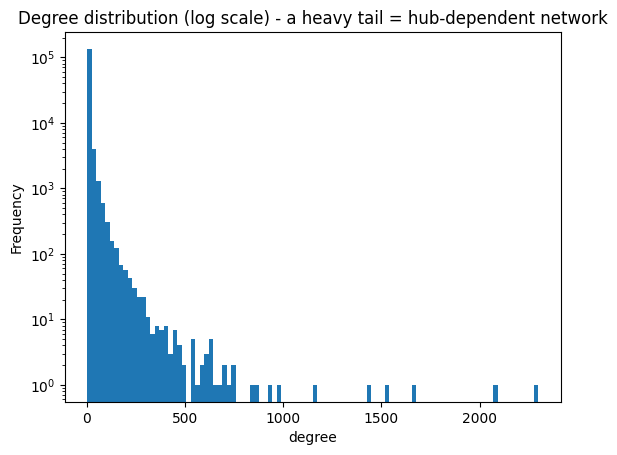

In [11]:
print("Density:", round(nx.density(G), 7), " (extremely sparse - relationships are costly)")
print("Weakly connected components:", nx.number_weakly_connected_components(G))
print(f"Giant component: {len(giant):,} of {G.number_of_nodes():,} firms")

pd.Series(dict(G.degree())).plot(kind='hist', bins=100, logy=True,
    title='Degree distribution (log scale) - a heavy tail = hub-dependent network')
plt.xlabel('degree'); plt.show()

---
# Visualization


### ▶ *Drawing a network in Python*

The full graph is too big to draw, so we draw a manageable slice: the top firms by degree and the links among them.

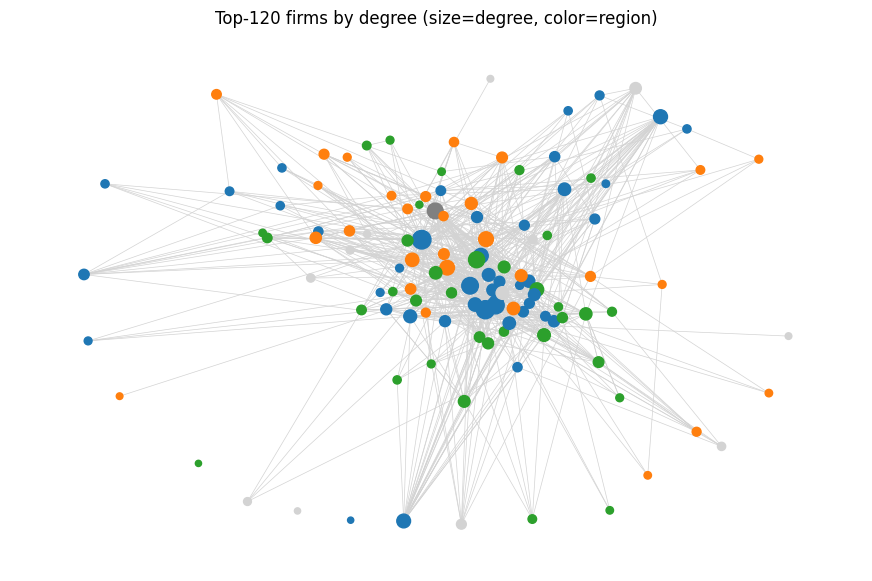

In [33]:
deg = pd.Series(dict(G.degree()))
top_nodes = deg.sort_values(ascending=False).head(120).index
S = G.subgraph(top_nodes)

pos = nx.spring_layout(S, seed=42, k=0.3)          # force-directed; SEED for reproducibility
region = nx.get_node_attributes(S, 'region')
palette = {'North America':'tab:blue','Europe':'tab:orange','Asia':'tab:green',
           'Pacific':'tab:purple','Middle East':'tab:red','Latin America':'tab:brown','Africa':'gray'}

plt.figure(figsize=(11,7))
nx.draw_networkx(S, pos, with_labels=False, arrows=False,
    node_color=[palette.get(region.get(n),'lightgray') for n in S],
    node_size=[20 + 3*S.degree(n) for n in S],
    edge_color='lightgray', width=0.5)
plt.axis('off'); plt.title('Top-120 firms by degree (size=degree, color=region)')
plt.show()

# Rerun with seed=7 and observe the shape moves but the STRUCTURE is the same.

### ▶ *Extracting one firm's tiers in code*

In [34]:
firm = boeing    # reuse Boeing from previos section

# upstream = suppliers: reverse the graph (arrows point TOWARD the focal firm)
up = nx.single_source_shortest_path_length(G.reverse(copy=False), firm, cutoff=2)
tier1_sup = [f for f, d in up.items() if d == 1]
tier2_sup = [f for f, d in up.items() if d == 2]

# downstream = customers: same call on G itself
down = nx.single_source_shortest_path_length(G, firm, cutoff=2)
tier1_cus = [f for f, d in down.items() if d == 1]
tier2_cus = [f for f, d in down.items() if d == 2]

print(f"{names.get(firm, firm)}:")
print(f"  suppliers  - tier 1: {len(tier1_sup):>4}   tier 2: {len(tier2_sup):>5}")
print(f"  customers  - tier 1: {len(tier1_cus):>4}   tier 2: {len(tier2_cus):>5}")
print("Notice how tier 2 explodes - that's the visibility problem.")

The Boeing Co.:
  suppliers  - tier 1:  252   tier 2:  2396
  customers  - tier 1:  173   tier 2:  1182
Notice how tier 2 explodes - that's the visibility problem.


### ▶ *One firm's network: suppliers vs. customers*

Draws the two-sided figure: suppliers (blue, left) vs customers (orange, right); dark=tier1, light=tier2.

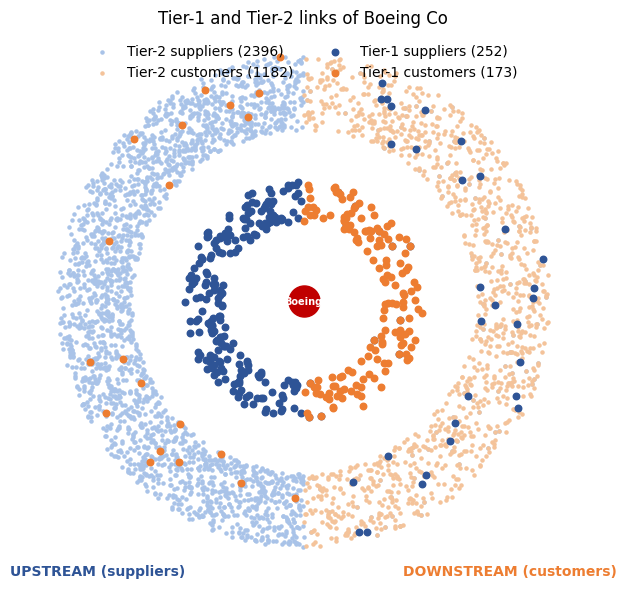

In [56]:
rng = np.random.default_rng(42)
def half_ring(members, r0, r1, side):     # side=-1 left (suppliers), +1 right (customers)
    a0, a1 = (np.pi/2, 3*np.pi/2) if side < 0 else (-np.pi/2, np.pi/2)
    th = rng.uniform(a0, a1, len(members)); r = rng.uniform(r0, r1, len(members))
    return {m:(rr*np.cos(t), rr*np.sin(t)) for m,t,rr in zip(members, th, r)}

pos = {firm:(0,0)}
pos.update(half_ring(tier1_sup,0.7,1.05,-1));
pos.update(half_ring(tier1_cus,0.7,1.05,+1));
pos.update(half_ring(tier2_sup,1.5,2.15,-1));
pos.update(half_ring(tier2_cus,1.5,2.15,+1));

plt.figure(figsize=(11,7)); ax = plt.gca()
ax.scatter(*zip(*[pos[n] for n in tier2_sup]), s=5,  c='#A9C3E8', label=f'Tier-2 suppliers ({len(tier2_sup)})')   # tier2 suppliers
ax.scatter(*zip(*[pos[n] for n in tier2_cus]), s=5,  c='#F4C39A', label=f'Tier-2 customers ({len(tier2_cus)})')   # tier2 customers
ax.scatter(*zip(*[pos[n] for n in tier1_sup]), s=22, c='#2E5496', label=f'Tier-1 suppliers ({len(tier1_sup)})')
ax.scatter(*zip(*[pos[n] for n in tier1_cus]), s=22, c='#ED7D31', label=f'Tier-1 customers ({len(tier1_cus)})')
ax.scatter([0],[0], s=500, c='#C00000', zorder=5)
ax.annotate(focal_firm_name.split()[0], (0,0), ha='center', va='center',
            color='white', fontweight='bold', zorder=6, fontsize=7)
ax.text(-1.8,-2.4,'UPSTREAM (suppliers)', ha='center', color='#2E5496', fontweight='bold')
ax.text( 1.8,-2.4,'DOWNSTREAM (customers)', ha='center', color='#ED7D31', fontweight='bold')
ax.legend(loc='upper center', ncol=2, frameon=False); ax.set_aspect('equal'); ax.axis('off')
plt.title(f"Tier-1 and Tier-2 links of {focal_firm_name}")
plt.show()

### ▶ *The geo-spatial view*

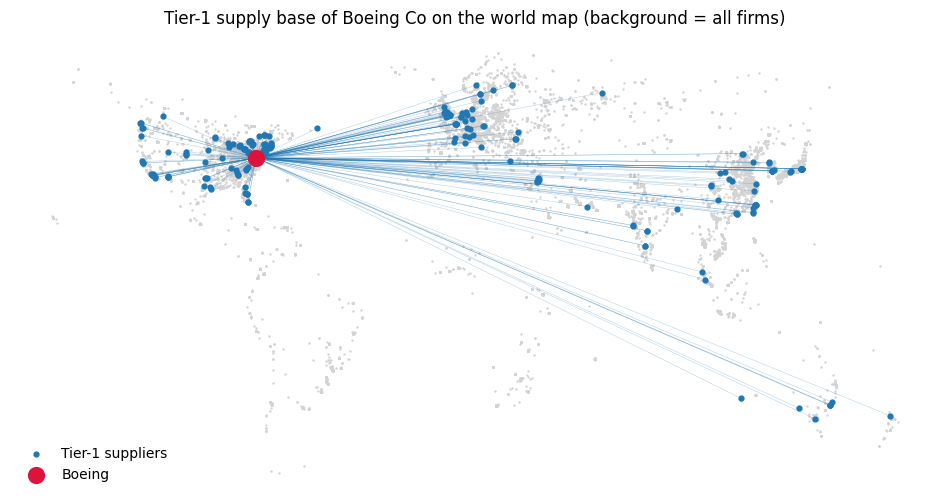

In [57]:
geo = nodes.set_index('feid')[['lat','lng']].dropna()
t1_geo = geo.reindex(tier1_sup).dropna()
fx, fy = geo.loc[firm, 'lng'], geo.loc[firm, 'lat']

plt.figure(figsize=(12,6))
plt.scatter(geo['lng'], geo['lat'], s=0.5, c='lightgray')          # every firm -> world map
for _, r in t1_geo.iterrows():
    plt.plot([r['lng'], fx], [r['lat'], fy], color='tab:blue', lw=0.3, alpha=0.4)

plt.scatter(t1_geo['lng'], t1_geo['lat'], s=12, c='tab:blue', label='Tier-1 suppliers')
plt.scatter([fx],[fy], s=130, c='crimson', label=focal_firm_name.split()[0], zorder=5)
plt.legend(loc='lower left', frameon=False); plt.axis('off')
plt.title(f"Tier-1 supply base of {focal_firm_name} on the world map (background = all firms)")
plt.show()

In [58]:
# Optional interactive version (plotly is preinstalled in Colab)
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scattergeo(
    lon=sum([[r['lng'], fx, None] for _, r in t1_geo.iterrows()], []),
    lat=sum([[r['lat'], fy, None] for _, r in t1_geo.iterrows()], []),
    mode='lines', line=dict(width=0.5, color='steelblue'), opacity=0.4,
    hoverinfo='skip', showlegend=False))
fig.add_trace(go.Scattergeo(lon=t1_geo['lng'], lat=t1_geo['lat'], mode='markers',
    marker=dict(size=5, color='steelblue'),
    text=names.reindex(t1_geo.index), name='Tier-1 suppliers'))
fig.add_trace(go.Scattergeo(lon=[fx], lat=[fy], mode='markers',
    marker=dict(size=12, color='crimson'), text=[names.get(firm, firm)], name='Focal firm'))
fig.update_layout(height=520, geo=dict(showland=True, landcolor='rgb(240,240,240)'),
                  title='Hover any supplier for its name')
fig.show()

### ▶ *A practical Gephi workflow* (export step)
Run this before recording to produce the file you open in Gephi.

In [62]:
focal_net = G.subgraph([firm] + tier1_sup + tier2_sup + tier1_cus + tier2_cus).copy()
# GEXF can't store NaN - blank them
for _, d in focal_net.nodes(data=True):
    for k, v in list(d.items()):
        if pd.isna(v): d[k] = ''
nx.write_gexf(focal_net, 'focal_2tier.gexf')
print(f"wrote focal_2tier.gexf: {focal_net.number_of_nodes():,} nodes - open this in Gephi")

wrote focal_2tier.gexf: 3,862 nodes - open this in Gephi


---
---
# Applications
*(Setup, the graph-build cell, and the betweenness cell from Video 2 should have been run this session.)*


### ▶ *The stress test, in code*

In [59]:
def stress_test(G, remove, source):
    H = G.copy()                                    # always copy - don't damage the real graph
    H.remove_nodes_from(remove)
    before = len(nx.descendants(G, source))
    after  = len(nx.descendants(H, source)) if source in H else 0
    return {'reach_before': before, 'reach_after': after,
            'lost_pct': round(100*(before - after)/max(before, 1), 1)}

# measure from a large supplier so there's a big reachable set to damage
source = pd.Series(dict(G.out_degree())).idxmax()
print("measuring reach from:", names.get(source, source))

measuring reach from: Alphabet, Inc.


In [60]:
# 1) remove the single top chokepoint (uses btw from the Video 2 betweenness cell)
chokepoint = pd.Series(btw).idxmax()
print("Remove", names.get(chokepoint, chokepoint), "->", stress_test(G, [chokepoint], source))

Remove Amazon.com, Inc. -> {'reach_before': 74893, 'reach_after': 74050, 'lost_pct': 1.1}


In [61]:
# 2) geopolitical variant: remove every firm in one country
country = 'Taiwan'
cty_firms = [f for f in G if G.nodes[f].get('country') == country]
print(f"Remove all {len(cty_firms):,} {country} firms ->", stress_test(G, cty_firms, source))

Remove all 1,644 Taiwan firms -> {'reach_before': 74893, 'reach_after': 72160, 'lost_pct': 3.6}
